In [72]:
# Auto-reload modules to ensure we use the latest code
%load_ext autoreload
%autoreload 2

import sys
import os

# Add parent directory to path to import from src/ - DO THIS FIRST
# Get the notebook's directory, then go up one level to project root
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# Now import everything - path is set up
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Adam

# Import PINN models from external module
from src.pinn_models import PressureHeadNet, WaterTableNet, RichardsPINN
# Import spike detection function from external module
from src.spike_detection import detect_spike_events
# Import normalization helper from external module
from src.normalization_helper import NormalizationHelper
# Import boundary sampling function from external module
from src.boundary_sampling import sample_boundary_points
# Import sampling helpers and loss computation functions from external module
from src.training_utils import (
    SamplingHelpers, 
    compute_losses, 
    apply_weights_and_compute_gradients, 
    apply_weights_fixed_mode
)
# Import WeightManager from external module
from src.training_utils import WeightManager
# Import CachePoolManager from external module
from src.training_utils import CachePoolManager
# Import gradient computation utilities from external module
from src.training_utils import compute_grad_norm, compute_total_grad_norm
# Import TrainingLogger from external module
from src.training_logger import TrainingLogger
#training function
from src.train_loop import train_pinn_pool_batch_autoweight
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(44)
np.random.seed(44)

print("✓ Modules loaded with autoreload enabled")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jasonjing/Documents/smap/SMAP-Recharge-Flux
Using device: cpu
✓ Modules loaded with autoreload enabled


Detected 5 initial spike points
Merged into 5 spike events
Total indices in merged events: 25
Generated 400 adaptive boundary samples
Sample range: [27000.000, 1285200.000]


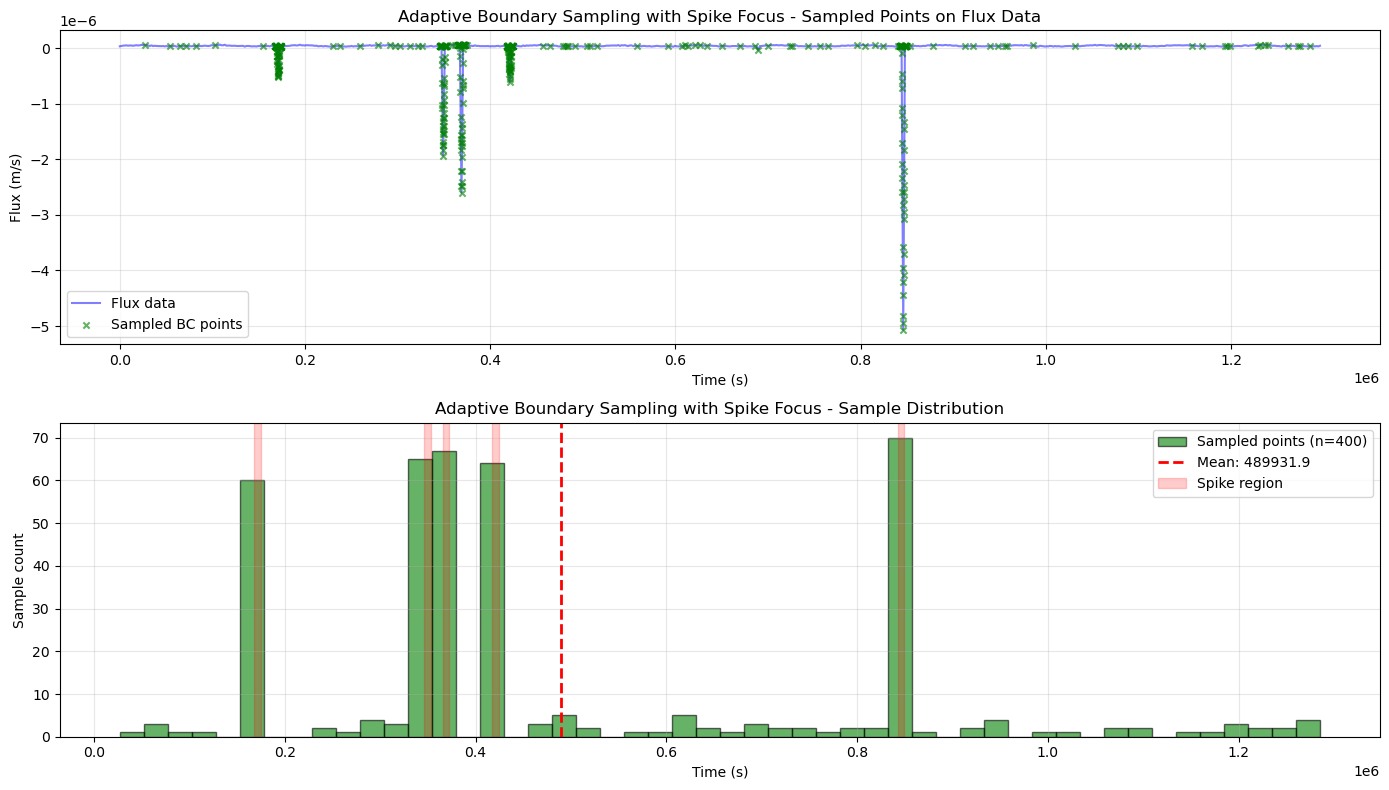

In [73]:
# Test adaptive boundary sampling and visualize the distribution
from src.adaptive_boundary_sampling import adaptive_boundary_sampling, visualize_sampling_distribution
from src.surf_flux import synth_surface_flux
t, q = synth_surface_flux(total_days=15, dt_minutes=30, storm_rate_per_day=0.4, min_storm_hours=0.5, max_storm_hours=0.5,  seed=16)
q_actual_flux = (t.tolist(), q.tolist())
q= torch.tensor(q_actual_flux[1]);

spike_events, total_spike_indices = detect_spike_events(
    q,
    threshold_method='std',      # or 'percentile' or 'iqr'
    threshold_value=1.0,         # 3 standard deviations
    expansion_window=2,          # expand ±5 points around spike
    merge_distance=3,            # merge events if gap ≤ 3 points
    min_event_size=2,            # keep events with at least 2 points
    device=device                # add device parameter
)

# Prepare time tensor for boundary sampling
q0_times_t = torch.tensor(q_actual_flux[0], dtype=torch.float32).to(device)
q0_values = torch.tensor(q_actual_flux[1], dtype=torch.float32).to(device)

# Test parameters
batch_size_bc = 400
n_events = 5
spike_ratio=0.8
interpolation_density=40
neighborhood_expansion=0
# Generate samples using the new adaptive sampling method
t_bc_adaptive = adaptive_boundary_sampling(
    q0_times_t, 
    spike_events, 
    n_events, 
    batch_size_bc, 
    device,
    spike_ratio=spike_ratio,              # 70% from spike regions
    interpolation_density=interpolation_density,      # 3 interpolated points between neighbors
    neighborhood_expansion=neighborhood_expansion,     # ±2 point expansion
    use_weighted_sampling=True    # Use importance weighting
)

# Visualize the sampling distribution
print(f"Generated {len(t_bc_adaptive)} adaptive boundary samples")
print(f"Sample range: [{t_bc_adaptive.min():.3f}, {t_bc_adaptive.max():.3f}]")

# Create visualization comparing original vs adaptive sampling
visualize_sampling_distribution(
    q0_times_t, 
    q0_values,
    spike_events, 
    t_bc_adaptive,
    title='Adaptive Boundary Sampling with Spike Focus'
)
plt.show()

In [ ]:
soil_params = {
    'theta_s': 0.4,
    'theta_r': 0.1,
    'alpha': 0.005,
    'n': 1.3,
    'Ks': 1e-5,
    'l': 0.5
}

# Define network configurations
h_net_config = {'hidden_dim': 64, 'num_layers': 4}
zb_net_config = {'hidden_dim': 32, 'num_layers': 3}

# Test the normalized PINN training
print("Testing Normalized Pool + Batch Training with Boundary Focus")
print("="*60)

# Train with pool + batch approach
model_pool, losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs = train_pinn_pool_batch_autoweight(
    soil_params=soil_params,
    q0_data=q_actual_flux,
    Sy=0.3,
    zr=0.5,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,
    L=4.0,  # ← ADD: Characteristic length scale (domain depth)
    S_max=1e-7,  # ← ADD: Maximum sink term
    n_epochs=0000,
    learning_rate=8e-4,
    zb_initial=1,
    weight_update_freq=1e10,
    weight_lr=0.1,
    use_initial_scales=True,  
    # Pool + batch parameters
    cache_size=10000,
    batch_size=500,
    resample_freq=500,
    boundary_ratio=0.7,
    high_residual_ratio=0.3,
    temperature=1.0,
    device=device,  # ← Add device parameter
    spike_events=spike_events,  # ← Add spike_events parameter
    checkpoint_dir='checkpoints_train',
    checkpoint_freq=5000,
    n_events=n_events,
    batch_size_bc=batch_size_bc,
    spike_ratio=spike_ratio,            # Try 80% spike focus
    interpolation_density=interpolation_density,    # Try 5 interpolated points
    neighborhood_expansion=neighborhood_expansion,   # Try ±3 expansion
    use_weighted_sampling=True,

)

Testing Normalized Pool + Batch Training with Boundary Focus

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.300
Time scale (T):             1.20e+05 s (33.33 hours)
Dimensionless α̃:            0.0200
Dimensionless S̃_max:        0.0400

Fixed weights mode enabled (weight_update_freq=10000000000.0 >= n_epochs=20000)
Checkpointing enabled: saving every 5000 epochs to checkpoints_train/
Training for 20000 epochs | lr=0.0008
Device: cpu | GPUs available: 0
Adaptive weighting: updating every 10000000000.0 epochs
Pool + Batch: cache_size=10000, batch_size=500, resample_freq=500
Boundary ratio: 70.0%, High residual ratio: 30.0%
Time domain from q0: t∈[0.000, 1296000.000], z adaptive in [-z_b(t), 0]
Initial weights: {'pde': 10.0, 'surf': 50.0, 'wt_head': 1.0, 'wt_kin': 1.0, 'ic_h': 1.0, 'ic_zb': 1.0}

[   1/20000]
  Losses: total=4.775e

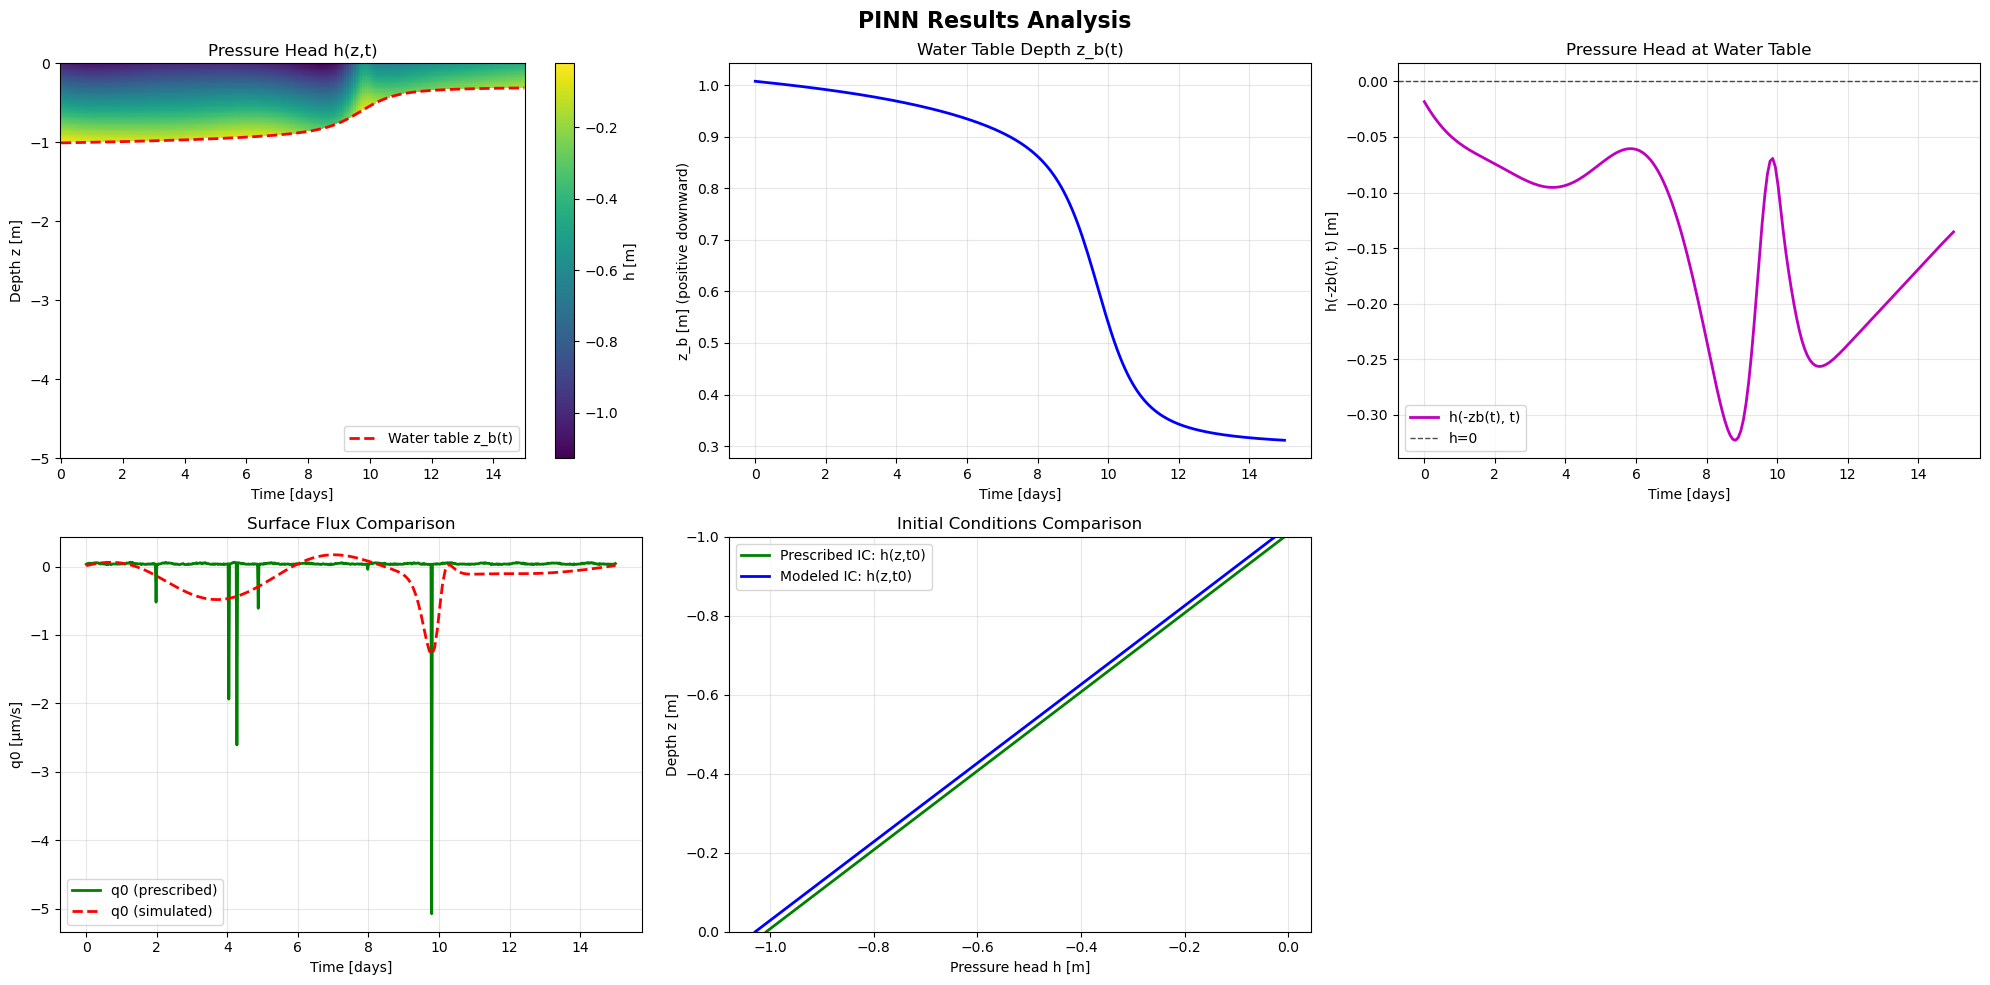


Summary Statistics:
Water table depth range: 0.311 to 1.007 m
Surface head range: -1.127 to -0.448 m
h(-zb(t), t) range: -0.322777 to -0.018349 m
Max |h(-zb(t), t)|: 0.322777 m (should be close to 0)
Max IC error: 0.021268 m


In [75]:
# Import visualization functions from external module
from src.visualization import plot_comprehensive_results
plot_comprehensive_results(model_pool, q_actual_flux, soil_params, device=device)

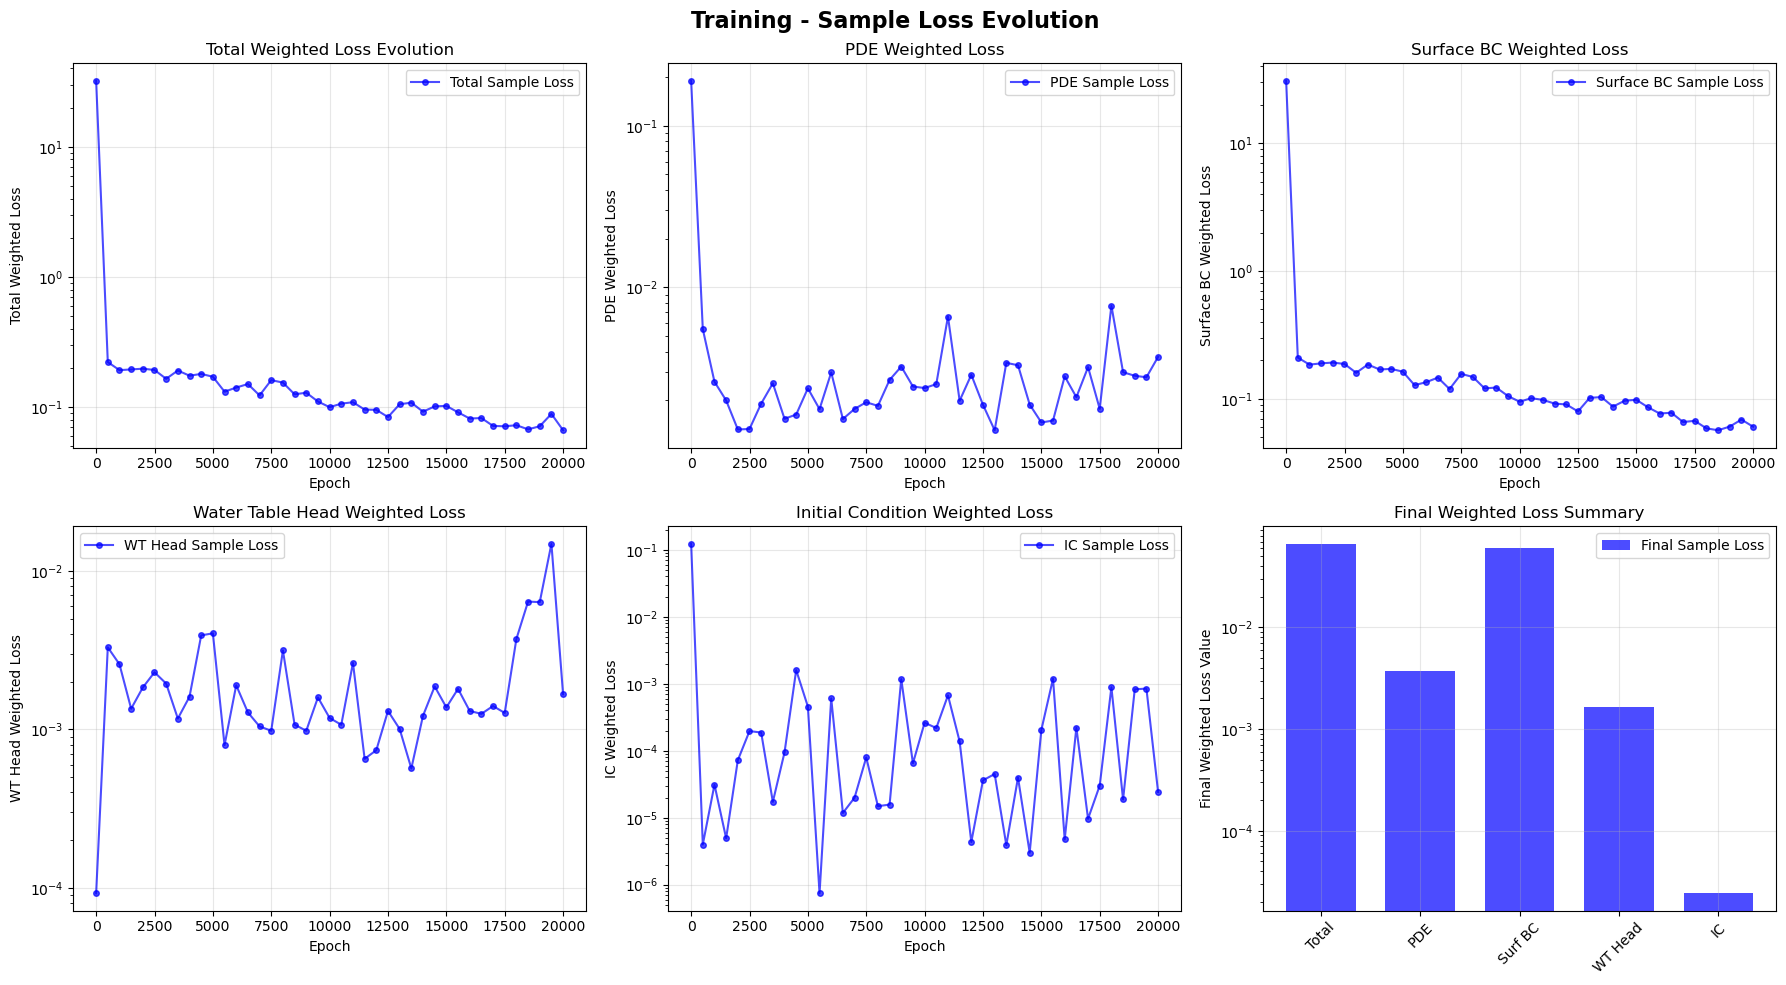

In [76]:
# Import and use the loss plotting function from external module
from src.visualization import plot_training_losses

# Plot the sample losses (computed over full dataset every 500 epochs)
# This gives a smoother, less noisy view of the loss evolution
plot_training_losses(losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs)